# **01. [Prostate] Preparation and Data Analysis**

## **Introduction**

Preparation and Analysis of RHC-SP Prostate Data for the Machine Learning Survival Study

## Environment Settings

In [ ]:
# download the file that contains the requirement management functions
!gdown 1563shEptjQS10FQbqjM-QsXot_cvHJBL --quiet
%run /content/bootstrap.py

# mount google drive
from google.colab import drive
drive.mount('/content/drive')

# put here the your Drive's path to the project
LOCAL_PROJECT_PATH = "/content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida"

set_project(LOCAL_PROJECT_PATH)
setup()

Mounted at /content/drive
Projeto definido: /content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida

Grupos disponíveis:
1. data_analysis
2. ml
3. Criar novo grupo

Escolha (ex: 1,3): 1

Lendo dependências de data_analysis:
  - lifelines==0.30.3
  - matplotlib==3.10.0
  - numpy==2.0.2
  - pandas==2.2.2
  - plotly==5.24.1
  - scikit-learn==1.6.1
  - seaborn==0.13.2

 Instalando dependências necessárias:
 + lifelines==0.30.3

⚠️ Dependências instaladas.
Reiniciando o kernel automaticamente...


<IPython.core.display.Javascript object>

### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler, QuantileTransformer, FunctionTransformer
from sklearn.metrics import roc_curve, roc_auc_score, auc, ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline

from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

##Funções

In [ ]:
def preparing_dataset(df, psa_gleason=False):
    """
    Prepares the dataset for analysis, applying necessary filters and transformations.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset to be prepared.

    Returns:
    --------
    pandas.DataFrame
        The dataset after the transformations.
    """

    df_aux = df.copy()

    # Prostate Cancer Topography (C61) - Filter for prostate cancer
    df_aux = df_aux[df_aux.TOPOGRUP == 'C61']
    print(df_aux.shape)

    # Residency - Filter for residents of SP
    df_aux = df_aux[df_aux.UFRESID == 'SP']

    # Microscopic Confirmation - Filter for records with microscopic confirmation (BASEDIAG == 3)
    df_aux = df_aux[df_aux.BASEDIAG == 3]

    # ECGRUP - Remove records with ECGRUP equal to X or Y
    df_aux = df_aux[~df_aux.ECGRUP.isin(['X','Y'])]

    # ECGRUP Categorization - Categorize ECGRUP into 'In Situ', 'Inicial' and 'Avançado'
    df_aux['ECGRUP_CAT'] = ['In Situ' if ec == 0 else 'Inicial' if ec in ['I', 'II'] else 'Avançado' for ec in df_aux.ECGRUP]

    # TMO and TMO after hospitalization - Remove patients who underwent TMO and TMO after hospitalization
    df_aux = df_aux[df_aux.TMO == 0]
    # df_aux = df_aux[df_aux.TMOAPOS == 0]  # Commented out

    # ANODIAG - Filter for diagnosis year before 2020 (commented out)
    # df_aux = df_aux[df_aux.ANODIAG < 2020]

    # Age - Remove age ranges 0-9 and 10-19
    df_aux = df_aux[~df_aux.FAIXAETAR.isin(['00-09', '10-19'])]

    # Date Columns - Convert to datetime objects
    list_datas = ['DTCONSULT', 'DTDIAG', 'DTTRAT', 'DTULTINFO']

    for col_data in list_datas:
        df_aux[col_data] = pd.to_datetime(df_aux[col_data])

    # Time Calculations - Calculate time differences in days
    df_aux['CONSDIAG'] = (df_aux.DTDIAG - df_aux.DTCONSULT).dt.days
    df_aux['DIAGTRAT'] = (df_aux.DTTRAT - df_aux.DTDIAG).dt.days
    df_aux['TRATCONS'] = (df_aux.DTTRAT - df_aux.DTCONSULT).dt.days
    df_aux['ULTIDIAG'] = (df_aux.DTULTINFO - df_aux.DTDIAG).dt.days
    df_aux[['DIAGTRAT', 'TRATCONS']] = df_aux[['DIAGTRAT', 'TRATCONS']].fillna(-1)

    # Time Categories - Create categorical variables for time differences
    df_aux['CONSDIAG_CAT'] = [0 if consdiag <= 30 else 1 if consdiag <= 60 else 2 for consdiag in df_aux.CONSDIAG]
    df_aux['TRATCONS_CAT'] = [3 if tratcons < 0 else 0 if tratcons <= 60 else 1 if tratcons <= 90 else 2 for tratcons in df_aux.TRATCONS]
    df_aux['DIAGTRAT_CAT'] = [3 if diagtrat < 0 else 0 if diagtrat <= 60 else 1 if diagtrat <= 90 else 2 for diagtrat in df_aux.DIAGTRAT]

    # DRS - Extract DRS number
    DRS_expand = df_aux.DRS.str.split(' ', expand=True)
    df_aux['DRS'] = DRS_expand[1]

    # DRS_INST - Extract DRS_INST number
    DRS_expand = df_aux.DRS_INST.str.split(' ', expand=True)
    df_aux['DRS_INST'] = DRS_expand[1]

    # Metastasis Presence - Create a column indicating the presence of metastasis
    df_aux['PRESENCA_META'] = 0
    df_aux.loc[df_aux.META01.notnull(), 'PRESENCA_META'] = 1

    # Recurrence Presence - Create a variable for presence of recurrence (0 = No, 1 = Yes)
    df_aux['PRESENCA_REC'] = [0 if rec == 1 else 1 for rec in df_aux.RECNENHUM]
    df_aux.loc[(df_aux.PRESENCA_REC == 0) & (df_aux.DTRECIDIVA.notnull()), 'PRESENCA_REC'] = 1

    # Outcome Variables - Create outcome variables (overall survival, cancer-specific survival, and survival at 1, 3, 5, 7 and 10 years)
    df_aux['obito_geral'] = 0
    df_aux['obito_cancer'] = 0

    df_aux['sobrevida_ano1'] = 0
    df_aux['sobrevida_ano3'] = 0
    df_aux['sobrevida_ano5'] = 0
    df_aux['sobrevida_ano7'] = 0
    df_aux['sobrevida_ano10'] = 0

    df_aux.loc[df_aux.ULTINFO > 2, 'obito_geral'] = 1
    df_aux.loc[df_aux.ULTINFO == 3, 'obito_cancer'] = 1

    df_aux.loc[df_aux.ULTIDIAG > 365.25, 'sobrevida_ano1'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 3*365.25, 'sobrevida_ano3'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 5*365.25, 'sobrevida_ano5'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 7*365.25, 'sobrevida_ano7'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 10*365.25, 'sobrevida_ano10'] = 1

    # Drop Unused Columns - Remove columns that will not be used in the analysis
    cols = df_aux.columns
    drop_cols = ['UFNASC', 'UFRESID', 'CIDADE', 'DTCONSULT', 'CLINICA', 'DTDIAG',
                 'BASEDIAG', 'TOPOGRUP', 'DESCTOPO', 'DESCMORFO', 'T', 'N', 'M',
                 'PT', 'PN', 'PM', 'S', 'G', 'LOCALTNM', 'IDMITOTIC', 'OUTRACLA',
                 'META01', 'META02', 'META03', 'META04', 'DTTRAT', 'NAOTRAT',
                 'TRATAMENTO', 'TRATHOSP', 'TRATFANTES', 'TRATFAPOS', 'NENHUMANT',
                 'CIRURANT', 'RADIOANT', 'QUIMIOANT', 'HORMOANT', 'TMOANT',
                 'IMUNOANT', 'OUTROANT', 'DTULTINFO', 'CICI', 'CICIGRUP',
                 'CICISUBGRU', 'FAIXAETAR', 'LATERALI', 'INSTORIG', 'PERDASEG',
                 'ERRO', 'DTRECIDIVA', 'RECNENHUM', 'RECLOCAL', 'RECREGIO',
                 'RECDIST', 'REC01', 'REC02', 'REC03', 'REC04', 'CIDO', 'DSCCIDO',
                 'HABILIT', 'HABIT11', 'HABILIT1', 'CIDADEH', 'CIDADE_INS',
                 'SEXO', 'TOPO', 'TMO', 'TMOAPOS']

    # Include PSA and GLEASON (commented out, but kept for reference)
    # if psa_gleason:
    #     df_aux = df_aux[df_aux.ANODIAG > 2011]
    #     for col in ['PSA', 'GLEASON']:
    #         drop_cols.remove(col)

    cols = cols.drop(drop_cols)

    return df_aux[cols]

# **Data Preparation**

Step responsible for organizing, cleaning, and transforming raw data into a format suitable for analysis and modeling.

In [ ]:
# Database - Set/2024
!gdown 1_CGn_150mpmfxwsyVyB5LTeqeAVgJKhB --quiet

In [ ]:
# Load Data and Display Information
df = pd.read_csv('pacigeral_set24.csv')  # Load the CSV file into a Pandas DataFrame
print(df.shape)  # Print the dimensions of the DataFrame (rows, columns)
df.head(3)  # Display the first 3 rows of the DataFrame

/tmp/ipykernel_3480/3771973193.py:2: DtypeWarning: Columns (24,25,26,33,37,79,90,91,92) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('pacigeral_set24.csv')  # Load the CSV file into a Pandas DataFrame


(1233793, 105)


,INSTITU,ESCOLARI,IDADE,SEXO,UFNASC,UFRESID,IBGE,CIDADE,CATEATEND,DTCONSULT,...,CIDO,DSCCIDO,HABILIT,HABIT11,HABILIT1,HABILIT2,CIDADEH,DRS_INST,RRAS_INST,CIDADE_INS
0,14,4,49,2,SC,SC,4209409,LAGUNA,9,2011-03-23,...,81603.0,COLANGIOCARCINOMA,14,Inativo,6,5,São Paulo,DRS 01 Grande Sao Paulo,RRAS 06,SAO PAULO
1,8672,9,54,1,SP,SP,3550308,SAO PAULO,9,2006-05-30,...,80903.0,CARCINOMA BASOCELULAR SOE,7,CACON com Serviço de Oncologia Pediátrica,3,2,São Paulo,DRS 01 Grande Sao Paulo,RRAS 06,SAO PAULO
2,19100,9,77,1,SP,SP,3504503,AVARE,9,2003-12-14,...,82113.0,ADENOCARCINOMA TUBULAR,14,Inativo,6,5,Avaré,DRS 06 Bauru,RRAS 09,AVARE


In [ ]:
# Prepare Data for Prostate Cancer Analysis
df_prost = preparing_dataset(df) # Prepare the data, filtering for cervical cancer (ICD-10 code 'C61')

print(df_prost.shape) # Print the shape (rows, columns) of the filtered DataFrame
df_prost.head(3) # Display the first 3 rows of the filtered DataFrame

(128575, 105)
(111491, 51)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,MORFO,EC,ECGRUP,PSA,...,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10
2,19100,9,77,3504503,9,1,82113,II,II,8,...,2,0,0,1,1,1,1,1,1,1
3,19100,9,55,3504503,9,1,81473,II,II,8,...,0,0,0,0,0,0,0,0,0,0
109,8,5,67,3550308,9,2,85503,II,II,8,...,0,0,1,0,0,1,1,1,1,1


In [ ]:
# Columns
df_prost.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'MORFO', 'EC', 'ECGRUP', 'PSA', 'GLEASON', 'NENHUM', 'CIRURGIA',
       'RADIO', 'QUIMIO', 'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS',
       'CIRURAPOS', 'RADIOAPOS', 'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS',
       'OUTROAPOS', 'ULTINFO', 'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG',
       'DRS', 'RRAS', 'DSCINST', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'RRAS_INST', 'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT',
       'DIAGTRAT_CAT', 'PRESENCA_META', 'PRESENCA_REC', 'obito_geral',
       'obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5',
       'sobrevida_ano7', 'sobrevida_ano10'],
      dtype='object')

In [ ]:
# Calculate and Adjust Survival Time in Months
df_prost['meses_diag'] = np.ceil(df_prost['ULTIDIAG']/30).astype(int) # Calculate survival time in months, rounding up

df_prost.loc[df_prost.meses_diag == 0, 'meses_diag'] = 1 # Ensure no survival time is zero (set to 1 month)
df_prost.loc[df_prost.meses_diag > 120, ['meses_diag', 'obito_geral']] = [121, 0] # Cap survival time at 61 months and set obito_geral to 0 for those exceeding the cap

df_prost.meses_diag.value_counts().sort_index().tail() # Display the value counts for the last few survival times (for checking)

,count
meses_diag,
117,436
118,469
119,415
120,499
121,22967


## **Information**

In [ ]:
df_prost.shape

(111491, 52)

In [ ]:
df_prost.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'MORFO', 'EC', 'ECGRUP', 'PSA', 'GLEASON', 'NENHUM', 'CIRURGIA',
       'RADIO', 'QUIMIO', 'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS',
       'CIRURAPOS', 'RADIOAPOS', 'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS',
       'OUTROAPOS', 'ULTINFO', 'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG',
       'DRS', 'RRAS', 'DSCINST', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'RRAS_INST', 'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT',
       'DIAGTRAT_CAT', 'PRESENCA_META', 'PRESENCA_REC', 'obito_geral',
       'obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5',
       'sobrevida_ano7', 'sobrevida_ano10', 'meses_diag'],
      dtype='object')

**General Columns**

In [ ]:
df_prost.obito_cancer.value_counts().sort_index()

,count
obito_cancer,
0,94037
1,17454


**Outputs**

In [ ]:
ano = df_prost[~((df_prost.obito_geral == 0) & (df_prost.sobrevida_ano5 == 0))]
print(ano.shape)
ano.sobrevida_ano5.value_counts().sort_index()

(80527, 49)


,count
sobrevida_ano5,
0,23577
1,56950


**Morphology**

In [ ]:
df_prost[df_prost['MORFO'].astype(str).str.endswith('2')].shape

(75, 49)

In [ ]:
df_prost[df_prost['MORFO'].astype(str).str.endswith('3')].shape

(111416, 49)

In [ ]:
print(np.sort(df_prost[df_prost['MORFO'].astype(str).str.endswith('3')].MORFO.unique()))

[80103 80133 80203 80213 80223 80313 80333 80413 80503 80523 80703 80763
 80823 81203 81233 81303 81403 81433 81473 81903 82003 82013 82103 82113
 82153 82303 82313 82463 82553 82603 82613 82623 82633 83103 83133 83233
 83823 84013 84403 84803 84813 84903 85003 85033 85253 85503 85513 85603
 85703 85713 85723 85733 85743 90143 90153]


**Morphologies with beginning = 9**

In [ ]:
morfos9 = [90143, 90153]
df_prost[df_prost.MORFO.isin(morfos9)]['MORFO'].value_counts().sort_index()

,count
MORFO,
90143,2
90153,8


In [ ]:
df_prost[df_prost.MORFO.isin(morfos9)].index

Index([ 397628,  405972,  405973,  405975,  406027,  406028,  406035,  998800,
       1012750, 1040019],
      dtype='int64')

In [ ]:
df_morfo_inicio9 = df.loc[df_prost[df_prost.MORFO.isin(morfos9)].index]
df_morfo_inicio9.shape

(10, 105)

In [ ]:
df_morfo_inicio9.to_csv('prostata_morfo_inicio9.csv', index=False)

**Morphologies with ending = 2**

In [ ]:
df_sem_insitu = df_prost[df_prost.ECGRUP_CAT != 'In Situ']

df_sem_insitu[df_sem_insitu['MORFO'].astype(str).str.endswith('2')].shape

(75, 49)

In [ ]:
df_sem_insitu[df_sem_insitu['MORFO'].astype(str).str.endswith('2')].index

Index([ 191055,  191258,  193533,  195608,  405958,  410889,  537033,  537131,
        537210,  537211,  537212,  537232,  537291,  550441,  551461,  552128,
        557462,  949551,  953221,  955096,  956051,  964329,  964334, 1015200,
       1015287, 1015359, 1015399, 1024795, 1024985, 1025486, 1025506, 1025901,
       1025902, 1025911, 1026280, 1026308, 1026310, 1026332, 1026374, 1026851,
       1026856, 1026859, 1026886, 1027443, 1027458, 1027472, 1027614, 1027706,
       1027804, 1027888, 1028059, 1028135, 1028688, 1028715, 1028895, 1028901,
       1028959, 1029386, 1039504, 1039862, 1039892, 1040163, 1043320, 1103875,
       1195879, 1196640, 1203399, 1207495, 1224972, 1225310, 1226329, 1226520,
       1226524, 1231099, 1231540],
      dtype='int64')

In [ ]:
df_morfo_final2 = df.loc[df_sem_insitu[df_sem_insitu['MORFO'].astype(str).str.endswith('2')].index]
df_morfo_final2.shape

(75, 105)

In [ ]:
df_morfo_final2.to_csv('prostata_morfo_final2.csv', index=False)

**Saving the database into a csv file**

In [ ]:
# Saving database
df_prost.to_csv('prostata.csv', index=False)

# **Scholarity**

In [ ]:
# Próstata
!gdown 11fPdksDJwZmv9s-AnWkpNQxuRcei8RLX --quiet

In [ ]:
df = pd.read_csv('/content/prostata.csv')
print(df.shape)
df.head(3)

(111491, 49)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,MORFO,EC,ECGRUP,NENHUM,...,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10
0,19100,9,77,3504503,9,1,82113,II,II,0,...,2,0,0,1,1,1,1,1,1,1
1,19100,9,55,3504503,9,1,81473,II,II,0,...,0,0,0,0,0,0,0,0,0,0
2,8,5,67,3550308,9,2,85503,II,II,0,...,0,0,1,0,0,1,1,1,1,1


In [ ]:
    # Retirada dos pacientes com ECGRUP_CAT = 'In Situ'
    df = df[~df.ECGRUP_CAT.isin(['In Situ'])]

    # Retirada de MORFO  com início 9
    df = df[~df.MORFO.astype(str).str.startswith('9')]

    # Retirada de MORFO com final 2
    df = df[~df.MORFO.astype(str).str.endswith('2')]

    # Retirada das colunas de sobrevida
    colunas_sobrev = ['sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'sobrevida_ano7', 'sobrevida_ano10']

    # Remover as colunas do DataFrame
    df = df.drop(columns=colunas_sobrev)


In [ ]:
    # Verificar o resultado
    df.shape

(111406, 44)

1. Retirar pacientes com ECGRUP_CAT = 'In Situ'
2. Retirar com MORFO com início 9
3. Retirar com MORFO com final 2
4. Retirar colunas: sobrevida_ano1, sobrevida_ano3, sobrevida_ano5, sobrevida_ano7, sobrevida_ano10


### Visualização dos dados / Gráficos

In [ ]:
teste = df.copy()

In [ ]:
teste.head(3)

,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,MORFO,EC,ECGRUP,NENHUM,...,RRAS_INST,ECGRUP_CAT,ULTIDIAG,CONSDIAG_CAT,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer
0,19100,9,77,3504503,9,1,82113,II,II,0,...,RRAS 09,Inicial,5149,0,2,2,0,0,1,1
1,19100,9,55,3504503,9,1,81473,II,II,0,...,RRAS 09,Inicial,308,0,0,0,0,0,0,0
2,8,5,67,3550308,9,2,85503,II,II,0,...,RRAS 06,Inicial,4610,0,0,0,0,1,0,0


In [ ]:
teste.info ()

<class 'pandas.core.frame.DataFrame'>
Index: 111406 entries, 0 to 111490
Data columns (total 44 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   INSTITU        111406 non-null  int64  
 1   ESCOLARI       111406 non-null  int64  
 2   IDADE          111406 non-null  int64  
 3   IBGE           111406 non-null  int64  
 4   CATEATEND      111406 non-null  int64  
 5   DIAGPREV       111406 non-null  int64  
 6   MORFO          111406 non-null  int64  
 7   EC             111406 non-null  object 
 8   ECGRUP         111406 non-null  object 
 9   NENHUM         111406 non-null  int64  
 10  CIRURGIA       111406 non-null  int64  
 11  RADIO          111406 non-null  int64  
 12  QUIMIO         111406 non-null  int64  
 13  HORMONIO       111406 non-null  int64  
 14  IMUNO          111406 non-null  int64  
 15  OUTROS         111406 non-null  int64  
 16  NENHUMAPOS     111406 non-null  int64  
 17  CIRURAPOS      111406 non-null  in

In [ ]:
teste.describe().T

,count,mean,std,min,25%,50%,75%,max
INSTITU,111406.0,1.097751e+05,201111.454598,4.0,16772.0,20737.0,35611.0,928940.0
ESCOLARI,111406.0,4.561173e+00,2.952769,1.0,2.0,3.0,9.0,9.0
IDADE,111406.0,6.757732e+01,8.754846,20.0,62.0,68.0,74.0,106.0
IBGE,111406.0,3.534062e+06,17224.861612,3500105.0,3518800.0,3538709.0,3550308.0,3557303.0
CATEATEND,111406.0,3.829722e+00,3.183061,1.0,2.0,2.0,9.0,9.0
DIAGPREV,111406.0,1.674838e+00,0.468437,1.0,1.0,2.0,2.0,2.0
MORFO,111406.0,8.398093e+04,1981.264600,80103.0,81403.0,85503.0,85503.0,85743.0
NENHUM,111406.0,7.514856e-02,0.263632,0.0,0.0,0.0,0.0,1.0
CIRURGIA,111406.0,4.353536e-01,0.495805,0.0,0.0,0.0,1.0,1.0
RADIO,111406.0,3.303413e-01,0.470338,0.0,0.0,0.0,1.0,1.0


In [ ]:
teste.describe(include=['object'])

,EC,ECGRUP,RRAS,DSCINST,RRAS_INST,ECGRUP_CAT
count,111406,111406,111406,111406,111406,111406
unique,9,4,18,79,18,2
top,II,II,RRAS 06,HOSP AMARAL CARVALHO,RRAS 06,Inicial
freq,37833,65986,26182,12560,41257,75119


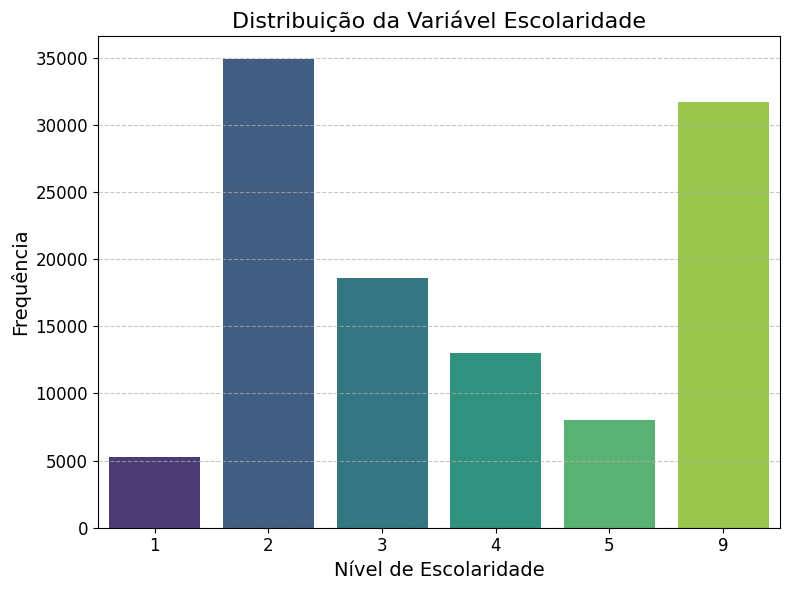

In [ ]:
# Gráfico de barras com Seaborn
plt.figure(figsize=(8, 6))
sns.countplot(data=teste, x='ESCOLARI', palette='viridis')

# Personalizações
plt.title('Distribuição da Variável Escolaridade', fontsize=16)
plt.xlabel('Nível de Escolaridade', fontsize=14)
plt.ylabel('Frequência', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir o gráfico
plt.tight_layout()
plt.show()


In [ ]:
y1=teste.ESCOLARI

In [ ]:
G2=pd.concat([y1,teste.iloc[:,[36]]],axis=1)

In [ ]:
datamelt1 = pd.melt(G2,id_vars="ESCOLARI",
                    var_name="features",
                    value_name='value')

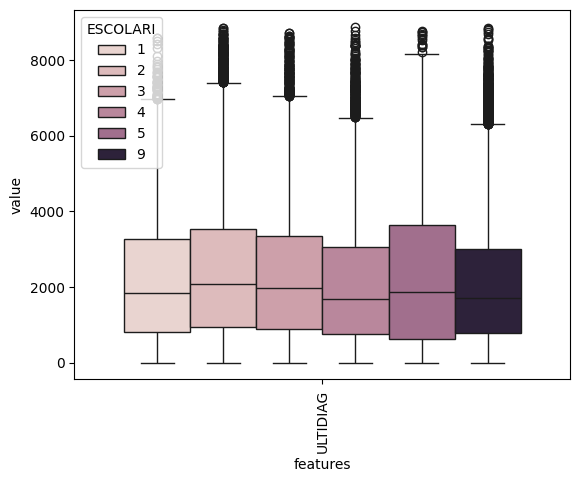

In [ ]:
sns.boxplot(x="features", y="value", hue="ESCOLARI", data=datamelt1)
plt.xticks(rotation=90)
plt.legend(title="ESCOLARI", loc='upper left')
#plt.ylim(2000,2044)


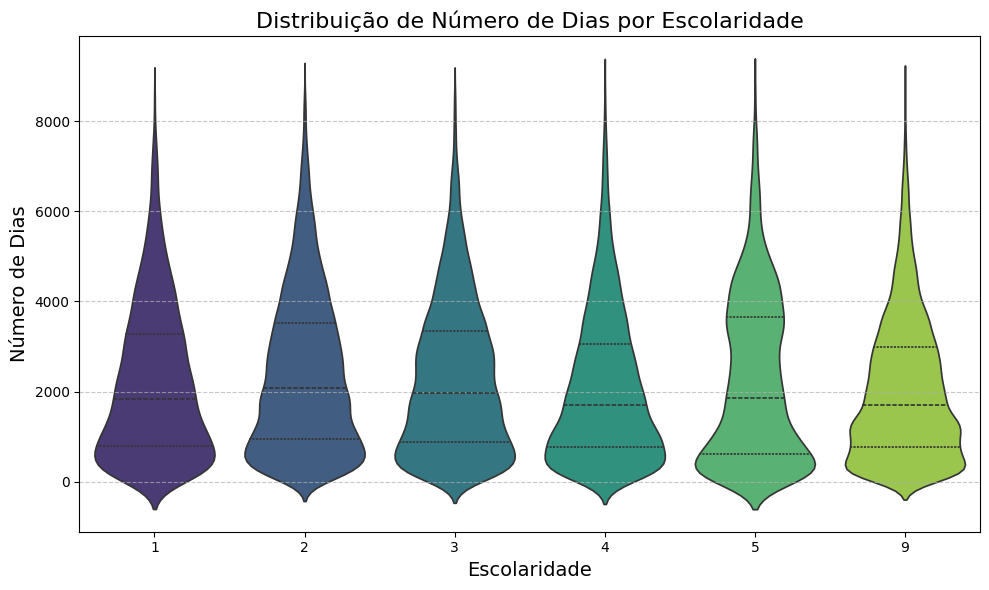

In [ ]:
#Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=teste, x='ESCOLARI', y='ULTIDIAG', palette='viridis', inner='quartile')

plt.title('Distribuição de Número de Dias por Escolaridade', fontsize=16)
plt.xlabel('Escolaridade', fontsize=14)
plt.ylabel('Número de Dias', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


###Correlação - Matriz correlação

Codificação

In [ ]:
# Criar uma cópia do DataFrame original
teste_original = teste.copy()

In [ ]:
# Lista de variáveis categóricas e ordinais
categorical_features = ['DSCINST', 'DRS', 'RRAS', 'DRS_INST', 'RRAS_INST']
ordinal_features = ['EC', 'ECGRUP', 'ECGRUP_CAT']

# Definição das categorias para codificação ordinal
EC_categories = ['I', 'IA', 'IB', 'II', 'IIA', 'IIB', 'III', 'IIIA', 'IIIB', 'IV']
ECGRUP_categories = ['I', 'II', 'III', 'IV']
ECGRUP_CAT_categories = ['Inicial', 'Avançado']

In [ ]:
# 1. Codificação Target Encoder para variáveis categóricas
target_encoder = TargetEncoder(cols=categorical_features)
teste[categorical_features] = target_encoder.fit_transform(teste[categorical_features], teste['ESCOLARI'])

# 2. Codificação Ordinal Encoder para variáveis ordinais
ordinal_encoder = OrdinalEncoder(categories=[EC_categories, ECGRUP_categories, ECGRUP_CAT_categories])
teste[ordinal_features] = ordinal_encoder.fit_transform(teste[ordinal_features])

Matriz de Correlação

In [ ]:
# Excluir pacientes com ESCOLARI = 9
testec = teste[teste['ESCOLARI'] != 9]
# Calcular a matriz de correlação
correlation_matrix = testec.corr()
#Selecionar apenas as correlações com a variável 'escolaridade'
escolaridade_corr= correlation_matrix['ESCOLARI']
# Ordenar as correlações de forma decrescente
escolaridade_corr_sorted = escolaridade_corr.sort_values(ascending=False)
#Remover a correlação da variável 'escolaridade' consigo mesma (que é 1)
escolaridade_corr_sorted = escolaridade_corr_sorted[escolaridade_corr_sorted < 1]
# Exibir as correlações ordenadas
print(escolaridade_corr_sorted)

DSCINST          0.268088
RRAS_INST        0.246737
IBGEATEN         0.234897
DRS_INST         0.232219
DRS              0.221517
RRAS             0.221367
HABILIT2         0.215683
CIRURGIA         0.146078
IBGE             0.139496
ANODIAG          0.128603
DIAGPREV         0.040025
QUIMIOAPOS       0.018653
CIRURAPOS        0.014053
HORMOAPOS        0.012456
MORFO            0.009941
OUTROAPOS        0.003984
RADIOAPOS        0.001854
NENHUM          -0.000233
IMUNO           -0.000508
IMUNOAPOS       -0.001887
DIAGTRAT        -0.006441
CONSDIAG        -0.017806
INSTITU         -0.022675
NENHUMAPOS      -0.025625
QUIMIO          -0.027989
OUTROS          -0.029495
TRATCONS        -0.032722
ULTIDIAG        -0.038832
PRESENCA_REC    -0.047526
EC              -0.050086
CONSDIAG_CAT    -0.060525
DIAGTRAT_CAT    -0.063035
ECGRUP_CAT      -0.065340
PRESENCA_META   -0.071025
ECGRUP          -0.073664
RADIO           -0.079955
TRATCONS_CAT    -0.080814
CATEATEND       -0.101238
obito_cancer

### **Imputação KNN**

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Input da ESCOLARI usando ECGRUP, IDADE e SEXO
cols_input = ['ESCOLARI', 'IBGEATEN', 'DSCINST', 'INSTITU', 'IBGE']

df_esc = teste_labels[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan

# Convert relevant columns to numeric if they are of object type
for col in ['IBGEATEN', 'DSCINST', 'INSTITU', 'IBGE']:
    if df_esc[col].dtype == 'object':
        # If the column is of object type, try converting to numeric
        # Errors='coerce' will replace non-numeric values with NaN
        df_esc[col] = pd.to_numeric(df_esc[col], errors='coerce')

X = df_esc.values
mms = MinMaxScaler()
X[:, 1:] = mms.fit_transform(X[:, 1:])

imputer = KNNImputer(n_neighbors=1, weights='distance')
teste_labels['ESCOLARI_PREENCH'] = imputer.fit_transform(X)[:,0].round()

teste_labels.ESCOLARI_PREENCH.value_counts().sort_index()

/usr/local/lib/python3.10/dist-packages/sklearn/utils/_array_api.py:695: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_array_api.py:712: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


,count
ESCOLARI_PREENCH,
1.0,7367
2.0,43905
3.0,26487
4.0,21018
5.0,10137


In [ ]:
escolari = teste_labels[teste_labels.ESCOLARI != 9]
escolari.ESCOLARI.value_counts().sort_index()

,count
ESCOLARI,
1,5190
2,34263
3,18159
4,12636
5,7812


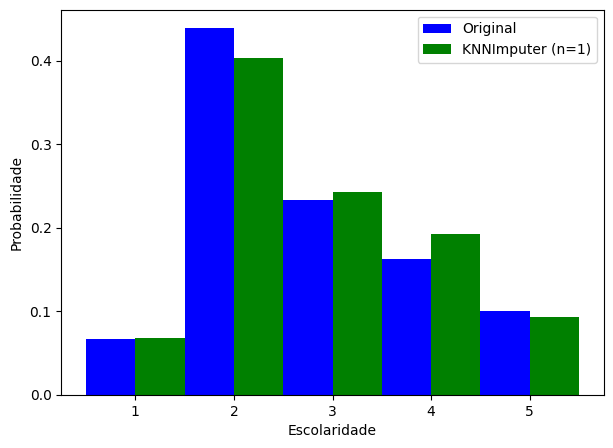

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = teste_labels.ESCOLARI_PREENCH.value_counts().sort_index().values/teste_labels.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste_labels.ESCOLARI_PREENCH)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

Estatística de teste: 0.034662164678950336
p-value: 6.697723094615439e-48

Rejeitamos a hipótese nula (as distribuições são diferentes)


### **Imputação Random Forest**

In [ ]:
# Listas de variáveis por tipo
categorical_features = ['DSCINST', 'TOPO','DRS', 'RRAS', 'DRSINST','RRASINST' ]
ordinal_features = ['EC', 'ECGRUP']

# Codificação manual usando LabelEncoder para cada variável categórica
for feature in categorical_features:
    label_encoder = LabelEncoder()
    teste[feature + '_encoded'] = label_encoder.fit_transform(teste[feature])

# Atualiza a lista de variáveis categóricas para usar as versões codificadas
categorical_features_encoded = [f"{feature}_encoded" for feature in categorical_features]

# Codificação ordinal com ordem específica para as variáveis ordinais
EC_categories = ['I', 'IA', 'IB', 'II', 'IIA', 'IIB', 'III', 'IIIA', 'IIIB', 'IV']
ECGRUP_categories = ['I','II', 'III','IV']

# Criação do ColumnTransformer com OrdinalEncoder para variáveis ordinais
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[EC_categories, ECGRUP_categories]), ordinal_features),
        ('num', 'passthrough', make_column_selector(dtype_include=['int64', 'float64'])),
        ('cat', 'passthrough', categorical_features_encoded)  # Mantém as variáveis categóricas codificadas
    ]
)

# Aplicar a transformação
preprocessed_data = preprocessor.fit_transform(teste)
columns = ordinal_features + list(teste.select_dtypes(include=['int64', 'float64']).columns) + categorical_features_encoded
df_preprocessed = pd.DataFrame(preprocessed_data, columns=columns)

# Separar os dados com e sem valores ausentes em "ESCOLARI"
df_with_esc = df_preprocessed[df_preprocessed['ESCOLARI'] != 9]  # Linhas com dados válidos
df_without_esc = df_preprocessed[df_preprocessed['ESCOLARI'] == 9]  # Linhas com dados ausentes

# Verificação para garantir que não há valores ausentes
print(df_with_esc['ESCOLARI'].isnull().sum())


0


In [ ]:
# Treinar o modelo RandomForestClassifier
X_train = df_with_esc.drop(columns=['ESCOLARI'])
y_train = df_with_esc['ESCOLARI']
X_pred = df_without_esc.drop(columns=['ESCOLARI'])

model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

# Prever os valores ausentes em "ESCOLARI"
imputed_values = model.predict(X_pred)

In [ ]:
# Substituir valores ausentes na coluna original
teste.loc[teste['ESCOLARI'] == 9, 'ESCOLARI'] = imputed_values

In [ ]:
escolari = teste_labels[teste_labels.ESCOLARI != 9]
escolari.ESCOLARI.value_counts().sort_index()

,count
ESCOLARI,
1,5190
2,34263
3,18159
4,12636
5,7812


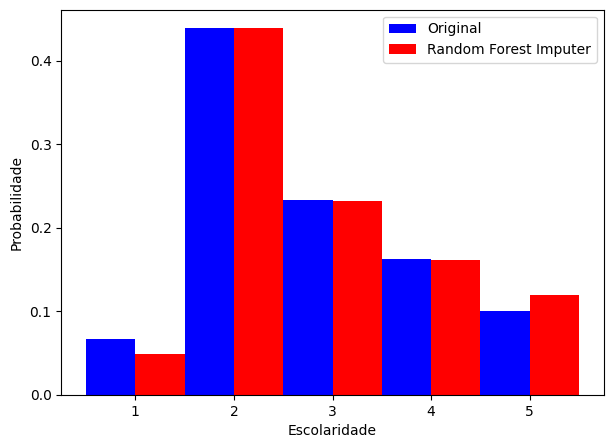

In [ ]:
# Adiciona a coluna ESCOLARI_PREENCH com os valores imputados pelo Random Forest
teste_labels = teste.copy()  # Cria uma cópia do DataFrame original
teste_labels['ESCOLARI_PREENCH'] = teste['ESCOLARI']

# Calcula a distribuição original e após a imputação com Random Forest
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
rf_imputed = teste_labels.ESCOLARI_PREENCH.value_counts().sort_index().values / teste_labels.shape[0]

# Plot das distribuições antes e depois da imputação com o Random Forest
plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color='b', width=0.5, label='Original')
plt.bar(x + 0.25, rf_imputed, color='r', width=0.5, label='Random Forest Imputer')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()
plt.show()


In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste_labels.ESCOLARI_PREENCH)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

Estatística de teste: 0.01950372256699595
p-value: 1.863141431567091e-15

Rejeitamos a hipótese nula (as distribuições são diferentes)


### **Input Escolaridade**

In [ ]:
teste_labels.ESCOLARI.value_counts().sort_index()

,count
ESCOLARI,
1,4791
2,30801
3,16024
4,10298
5,6610
9,27235


In [ ]:
teste_labels.ESCOLARI.value_counts(normalize=True).sort_index()

,proportion
ESCOLARI,
1,0.050032
2,0.321651
3,0.167337
4,0.107541
5,0.069027
9,0.284412


In [ ]:
escolari = teste_labels[teste_labels.ESCOLARI != 9]
escolari.ESCOLARI.value_counts().sort_index()

,count
ESCOLARI,
1,4791
2,30801
3,16024
4,10298
5,6610


### **KNNImputer**

In [ ]:
teste_labels.columns

Index(['INSTITU', 'DSCINST', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND',
       'DIAGPREV', 'TOPO', 'MORFO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA',
       'RADIO', 'QUIMIO', 'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS',
       'CIRURAPOS', 'RADIOAPOS', 'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS',
       'OUTROAPOS', 'ULTINFO', 'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG',
       'DRS', 'RRAS', 'IBGEATEN', 'DRSINST', 'RRASINST', 'CIDADEINST',
       'HABILIT2', 'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_META', 'PRESENCA_REC', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'sobrevida_ano7',
       'sobrevida_ano10', 'ESCOLARI_PREENCH'],
      dtype='object')

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Input da ESCOLARI usando ECGRUP, IDADE e SEXO
cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'CATEATEND', 'MORFO']

df_esc = teste_labels[cols_input].copy()
df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

X = df_esc.values
mms = MinMaxScaler()
X[:, 1:] = mms.fit_transform(X[:, 1:])

imputer = KNNImputer(n_neighbors=1, weights='distance')
teste_labels['ESCOLARI_PREENCH'] = imputer.fit_transform(X)[:,0].round()

teste_labels.ESCOLARI_PREENCH.value_counts().sort_index()

,count
ESCOLARI_PREENCH,
1.0,6315
2.0,42032
3.0,23406
4.0,15326
5.0,8680


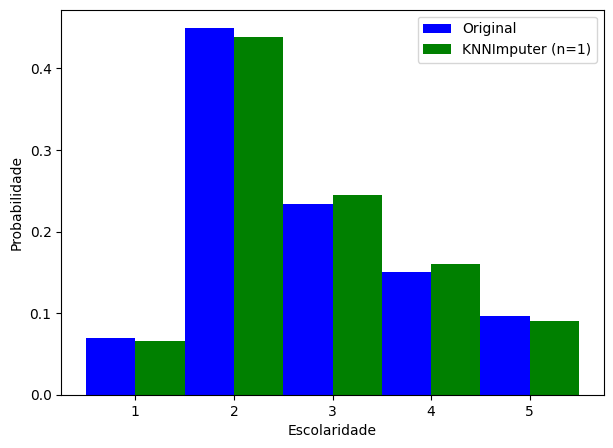

In [ ]:
x = np.sort(escolari.ESCOLARI.unique())
inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
knn1 = teste_labels.ESCOLARI_PREENCH.value_counts().sort_index().values/teste_labels.shape[0]

plt.figure(figsize=(7, 5))
plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
plt.ylabel("Probabilidade")
plt.xlabel("Escolaridade")
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Realize o teste de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(escolari.ESCOLARI, teste_labels.ESCOLARI_PREENCH)

# Exiba o resultado do teste
print('Estatística de teste:', statistic)
print('p-value:', p_value)

# Verifique se a diferença entre as distribuições é significativa
alpha = 0.05
if p_value > alpha:
    print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
else:
    print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

Estatística de teste: 0.014527210429734594
p-value: 9.437949670373948e-08

Rejeitamos a hipótese nula (as distribuições são diferentes)


# **Data Exploration**

## **Data**

In [ ]:
# Prostate Dataset
!gdown 11fPdksDJwZmv9s-AnWkpNQxuRcei8RLX --quiet

In [ ]:
df = pd.read_csv('/content/prostata.csv')
print(df.shape)
df.head(3)

(111491, 52)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,MORFO,EC,ECGRUP,PSA,...,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag
0,19100,9,77,3504503,9,1,82113,II,II,8,...,0,0,0,1,1,1,1,1,1,121
1,19100,9,55,3504503,9,1,81473,II,II,8,...,0,0,0,0,0,0,0,0,0,11
2,8,5,67,3550308,9,2,85503,II,II,8,...,0,1,0,0,1,1,1,1,1,121


In [ ]:
df.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'MORFO', 'EC', 'ECGRUP', 'PSA', 'GLEASON', 'NENHUM', 'CIRURGIA',
       'RADIO', 'QUIMIO', 'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS',
       'CIRURAPOS', 'RADIOAPOS', 'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS',
       'OUTROAPOS', 'ULTINFO', 'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG',
       'DRS', 'RRAS', 'DSCINST', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'RRAS_INST', 'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT',
       'DIAGTRAT_CAT', 'PRESENCA_META', 'PRESENCA_REC', 'obito_geral',
       'obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5',
       'sobrevida_ano7', 'sobrevida_ano10', 'meses_diag'],
      dtype='object')

### **Casos e óbitos**

In [ ]:
# Exclude patients with morphology ending in 2
df = df[~df['MORFO'].astype(str).str.endswith('2')]

# Exclude patients with morphology starting with 9
df = df[~df.MORFO.isin([90143, 90153])]

df.shape

(111406, 52)

In [ ]:
# --- Calculate total cases per diagnosis year ---
# Extract 'ANODIAG' column, count occurrences per year, and sort by year index
ano = df.ANODIAG.value_counts().sort_index()

# Convert Series to DataFrame for structural consistency
ano = pd.DataFrame(ano)

# --- Add death counts to the DataFrame ---
# Calculate total deaths by grouping by diagnosis year and summing 'obito_geral' (death indicator)
# The index alignment ensures matching with existing 'ano' index
ano['obito'] = df.groupby('ANODIAG').obito_geral.sum()

In [ ]:
# Import Plotly's graph objects module for advanced visualizations
import plotly.graph_objects as go

# Initialize a blank Figure object
fig = go.Figure()

# Background layer: Total cases (with reduced opacity for visibility)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['count'],                  # Total case counts on y-axis
    name="Total cases",              # Legend label
    marker_color='blue',             # Base color for total cases
    opacity=0.6                      # Partial transparency for overlay effect
))

# Foreground layer: Deaths (more opaque for emphasis)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['obito'],                  # Death counts on y-axis
    name="Deaths",                   # Legend label
    marker_color='red',              # Highlight color for deaths
    opacity=0.8                      # Higher opacity for visual prominence
))

# Critical layout configuration for proper overlay
fig.update_layout(
    barmode='overlay',               # Overlap bars instead of stacking
    title_text="Prostate Cancer",    # Chart title
    xaxis_tickangle=-45,             # Rotate x-axis labels for readability
    xaxis=dict(
        tickmode='linear',          # Show every year
        tick0=2000,                 # First tick at year 2000
        dtick=1,                    # Tick interval = 1 year
        title_text="Year of diagnosis"  # X-axis label (fixed typo)
    ),
    yaxis=dict(
        title_text="Number of patients"  # Y-axis label
    )
)

# Display the interactive visualization
fig.show()

In [ ]:
# --- Calculate total cases per diagnosis year ---
# Extract 'ANODIAG' column, count occurrences per year, and sort by year index
ano = df.ANODIAG.value_counts().sort_index()

# Convert Series to DataFrame for structural consistency
ano = pd.DataFrame(ano)

# --- Add death y cancer counts to the DataFrame ---
# Calculate total deaths by cancer by grouping by diagnosis year and summing 'obito_cancer' (death indicator)
# The index alignment ensures matching with existing 'ano' index
ano['obito_cancer'] = df.groupby('ANODIAG').obito_cancer.sum()
ano

,count,obito_cancer
ANODIAG,,
2000,1869,729
2001,2043,728
2002,2370,837
2003,2625,845
2004,3437,917
2005,3725,933
2006,3767,876
2007,3876,899
2008,4523,943


In [ ]:
# Import Plotly's graph objects module for advanced visualizations
import plotly.graph_objects as go

# Initialize a blank Figure object
fig = go.Figure()

# Background layer: Total cases (with reduced opacity for visibility)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['count'],                  # Total case counts on y-axis
    name="Total cases",              # Legend label
    marker_color='blue',             # Base color for total cases
    opacity=0.6                      # Partial transparency for overlay effect
))

# Foreground layer: Deaths (more opaque for emphasis)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['obito_cancer'],           # Death counts on y-axis
    name="Deaths by cancer",         # Legend label
    marker_color='red',              # Highlight color for deaths
    opacity=0.8                      # Higher opacity for visual prominence
))

# Critical layout configuration for proper overlay
fig.update_layout(
    barmode='overlay',               # Overlap bars instead of stacking
    title_text="Prostate Cancer",    # Chart title
    xaxis_tickangle=-45,             # Rotate x-axis labels for readability
    xaxis=dict(
        tickmode='linear',           # Show every year
        tick0=2000,                  # First tick at year 2000
        dtick=1,                     # Tick interval = 1 year
        title_text="Year of diagnosis"  # X-axis label (fixed typo)
    ),
    yaxis=dict(
        title_text="Number of patients"  # Y-axis label
    )
)

# Display the interactive visualization
fig.show()

## **Kaplan-Meier Curves**

**EC e Habilit2**

In [ ]:
df.ECGRUP_CAT.value_counts().sort_index()

,count
ECGRUP_CAT,
Avançado,36287
Inicial,75119


In [ ]:
df.ECGRUP.value_counts().sort_index()

,count
ECGRUP,
I,9133
II,65986
III,18659
IV,17628


In [ ]:
df.HABILIT2.value_counts().sort_index()

,count
HABILIT2,
1,45786
2,57784
3,1083
4,2750
5,4003


In [ ]:
df_habilit = df[df.HABILIT2.isin([1, 2, 3])]
print(df_habilit.shape)
df_habilit.HABILIT2.value_counts().sort_index()

(104653, 52)


,count
HABILIT2,
1,45786
2,57784
3,1083


In [ ]:
df_habilit.ECGRUP.value_counts().sort_index()

,count
ECGRUP,
I,8697
II,61342
III,17696
IV,16918


In [ ]:
df_ec1 = df_habilit[df_habilit.ECGRUP == 'I']
df_ec2 = df_habilit[df_habilit.ECGRUP == 'II']
df_ec3 = df_habilit[df_habilit.ECGRUP == 'III']
df_ec4 = df_habilit[df_habilit.ECGRUP == 'IV']

df_ec1.shape, df_ec2.shape, df_ec3.shape, df_ec4.shape

((8697, 52), (61342, 52), (17696, 52), (16918, 52))

log-rank p-value:
    CACON com UNACON = 0.7194
    CACON com Hosp. Geral = 0.4054



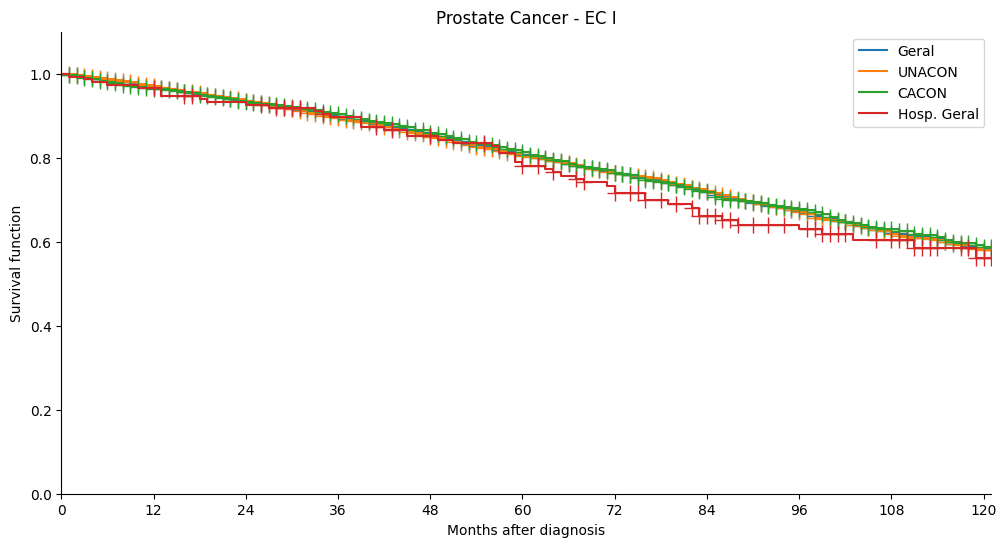

In [ ]:
data = df_ec1

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Prostate Cancer - EC I'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 132, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 121]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

log-rank p-value:
    CACON com UNACON = 4.766e-69
    CACON com Hosp. Geral = 0.0003765



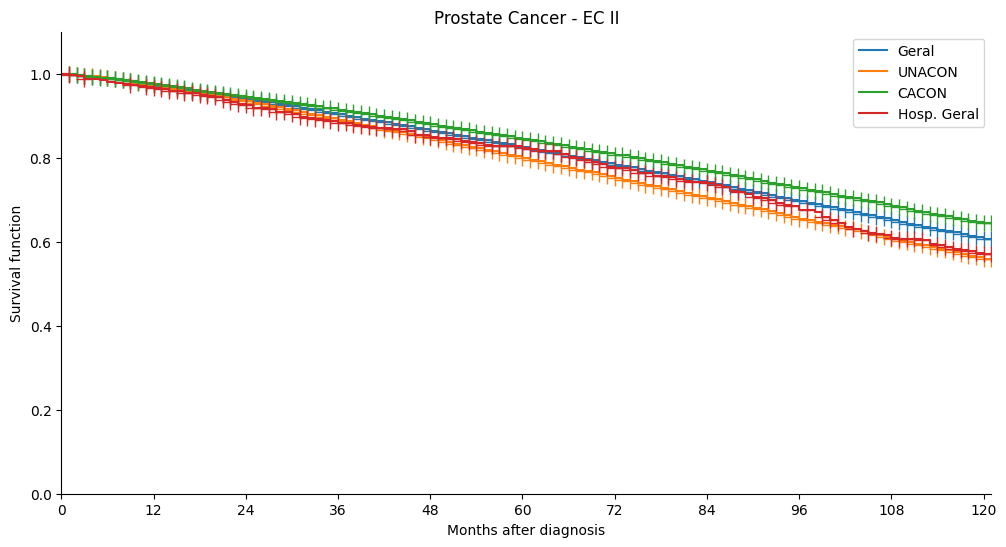

In [ ]:
data = df_ec2

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Prostate Cancer - EC II'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 132, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 121]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

log-rank p-value:
    CACON com UNACON = 4.79e-13
    CACON com Hosp. Geral = 4.213e-05



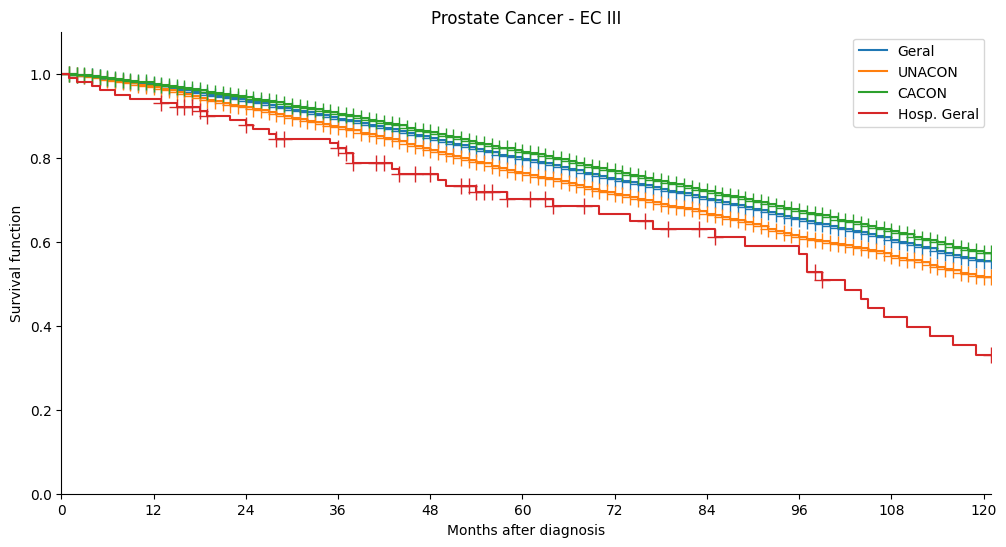

In [ ]:
data = df_ec3

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Prostate Cancer - EC III'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 132, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 121]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

log-rank p-value:
    CACON com UNACON = 0.4058
    CACON com Hosp. Geral = 0.5567



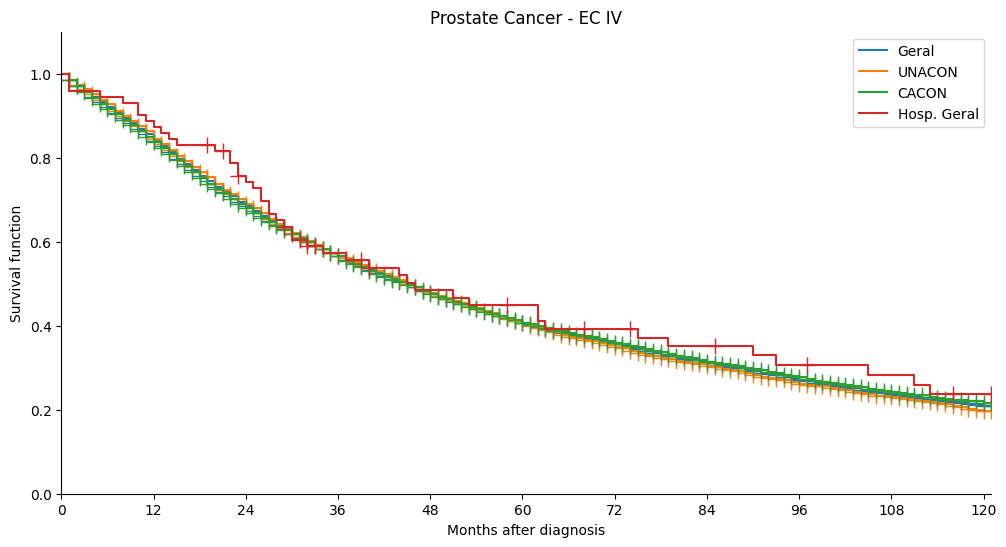

In [ ]:
data = df_ec4

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Prostate Cancer - EC IV'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 132, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 121]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

**DRS**

In [ ]:
df.DRS.value_counts().sort_index()

,count
DRS,
1,40487
2,3061
3,3503
4,3309
5,2388
6,7994
7,7884
8,2360
9,5016


In [ ]:
results_drs = pd.DataFrame(columns=['DRS', 'Total', 'Inicial', 'Avançado', 'mean',
                                    'min', '25%', '50%', '75%', 'max'])

list_drs = np.sort(df.DRS.unique())

for n_drs in list_drs:

    df_drs = df[df.DRS == n_drs]

    n = df_drs.shape[0]
    ini = df_drs.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Inicial']
    avanc = df_drs.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Avançado']

    E = (df_drs.obito_geral == 1)
    T = df_drs.meses_diag

    kmf = KaplanMeierFitter()

    surv_info = kmf.fit(T, E).survival_function_.describe().T[['mean', 'min', '25%', '50%', '75%', 'max']].values[0]

    new = {'DRS': n_drs, 'Total': n, 'Inicial': ini, 'Avançado': avanc,
           'mean': surv_info[0], 'min': surv_info[1], '25%': surv_info[2],
           '50%': surv_info[3], '75%': surv_info[4], 'max': surv_info[5]}

    results_drs = pd.concat([results_drs, pd.DataFrame([new])], ignore_index=True)

results_drs

,DRS,Total,Inicial,Avançado,mean,min,25%,50%,75%,max
0,1,40487,0.671228,0.328772,0.773082,0.560711,0.663666,0.769899,0.881999,1.0
1,2,3061,0.643581,0.356419,0.767066,0.538451,0.648086,0.769152,0.880210,1.0
2,3,3503,0.678276,0.321724,0.738767,0.514858,0.615584,0.730109,0.853522,1.0
3,4,3309,0.689634,0.310366,0.801965,0.607283,0.696670,0.805362,0.904441,1.0
4,5,2388,0.533501,0.466499,0.747941,0.519209,0.632158,0.742981,0.862111,1.0
5,6,7994,0.690643,0.309357,0.743804,0.536243,0.631464,0.729887,0.849312,1.0
6,7,7884,0.678590,0.321410,0.759583,0.536275,0.647483,0.752388,0.869017,1.0
7,8,2360,0.513983,0.486017,0.739374,0.517063,0.623979,0.725639,0.859452,1.0
8,9,5016,0.705343,0.294657,0.723987,0.493663,0.593607,0.710746,0.845126,1.0
9,10,4758,0.711013,0.288987,0.741385,0.509780,0.617305,0.732151,0.862839,1.0


In [ ]:
def plot_km_drs(df, n_drs):

    data = df[df.DRS == n_drs]

    E = (data.obito_geral == 1)
    T = data.meses_diag
    title = f'Prostate Cancer - DRS {n_drs}'

    kmf = KaplanMeierFitter()

    fig = plt.figure(figsize=(12, 6))
    ax = plt.subplot(111)
    ax = kmf.fit(T, E, #label=f'DRS {n_drs}'
    ).plot(ax=ax, ci_show=False, show_censors=True)

    ax.set_title(title)
    ax.set_xlabel('Months after diagnosis')
    ax.set_ylabel('Survival function')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(np.arange(0, 132, 12))
    plt.ylim([0, 1.1])
    plt.xlim([0, 121]);

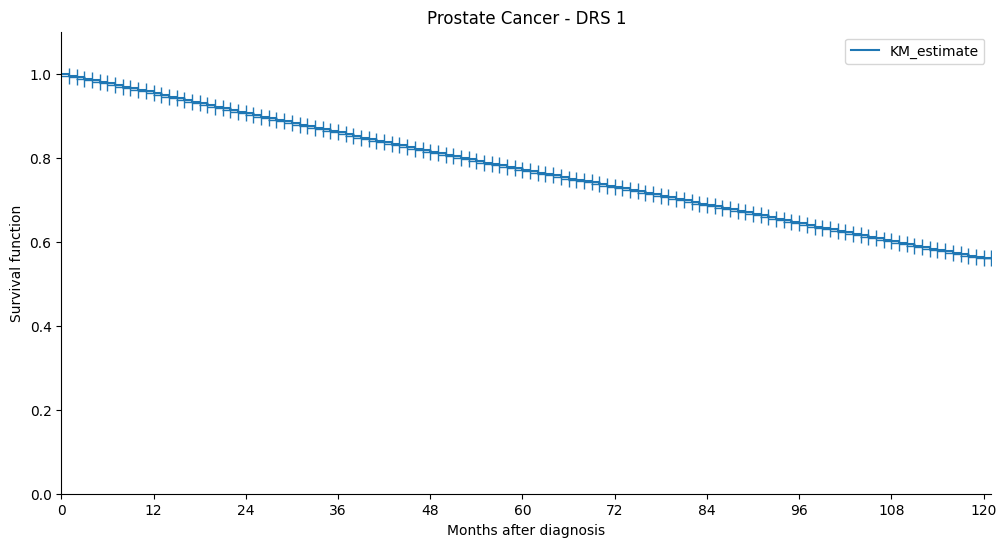

In [ ]:
plot_km_drs(df, 1)

In [ ]:
results_drs.to_csv('results_drs.csv', index=False)

**RRAS**

In [ ]:
df.RRAS.value_counts().sort_index()

,count
RRAS,
RRAS 01,3969
RRAS 02,3610
RRAS 03,674
RRAS 04,2234
RRAS 05,3818
RRAS 06,26182
RRAS 07,3757
RRAS 08,5592
RRAS 09,7994


In [ ]:
results_rras = pd.DataFrame(columns=['RRAS', 'Total', 'Inicial', 'Avançado',
                                     'mean', 'min', '25%', '50%', '75%', 'max'])

list_rras = np.sort(df.RRAS.unique())

for n_rras in list_rras:

    df_rras = df[df.RRAS == n_rras]

    n = df_rras.shape[0]
    ini = df_rras.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Inicial']
    avanc = df_rras.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Avançado']

    E = (df_rras.obito_geral == 1)
    T = df_rras.meses_diag

    kmf = KaplanMeierFitter()

    surv_info = kmf.fit(T, E).survival_function_.describe().T[['mean', 'min', '25%', '50%', '75%', 'max']].values[0]

    new = {'RRAS': n_rras, 'Total': n, 'Inicial': ini, 'Avançado': avanc,
           'mean': surv_info[0], 'min': surv_info[1], '25%': surv_info[2],
           '50%': surv_info[3], '75%': surv_info[4], 'max': surv_info[5]}

    results_rras = pd.concat([results_rras, pd.DataFrame([new])], ignore_index=True)

results_rras

,RRAS,Total,Inicial,Avançado,mean,min,25%,50%,75%,max
0,RRAS 01,3969,0.673721,0.326279,0.785982,0.561829,0.673828,0.787375,0.902714,1.0
1,RRAS 02,3610,0.650416,0.349584,0.786358,0.572439,0.675139,0.789428,0.896146,1.0
2,RRAS 03,674,0.649852,0.350148,0.767776,0.553591,0.660295,0.755594,0.894268,1.0
3,RRAS 04,2234,0.661146,0.338854,0.763763,0.543809,0.644394,0.764128,0.879978,1.0
4,RRAS 05,3818,0.646936,0.353064,0.793600,0.576941,0.686904,0.795743,0.903044,1.0
5,RRAS 06,26182,0.678672,0.321328,0.767467,0.557781,0.658879,0.762254,0.874250,1.0
6,RRAS 07,3757,0.706947,0.293053,0.803292,0.604978,0.698390,0.806843,0.907167,1.0
7,RRAS 08,5592,0.684013,0.315987,0.778660,0.565082,0.669192,0.770036,0.887531,1.0
8,RRAS 09,7994,0.690643,0.309357,0.743804,0.536243,0.631464,0.729887,0.849312,1.0
9,RRAS 10,5016,0.705343,0.294657,0.723987,0.493663,0.593607,0.710746,0.845126,1.0


In [ ]:
def plot_km_rras(df, n_rras):

    data = df[df.RRAS == n_rras]

    E = (data.obito_geral == 1)
    T = data.meses_diag
    title = f'Prostate Cancer - {n_rras}'

    kmf = KaplanMeierFitter()

    fig = plt.figure(figsize=(12, 6))
    ax = plt.subplot(111)
    ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True)

    ax.set_title(title)
    ax.set_xlabel('Months after diagnosis')
    ax.set_ylabel('Survival function')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(np.arange(0, 132, 12))
    plt.ylim([0, 1.1])
    plt.xlim([0, 121]);

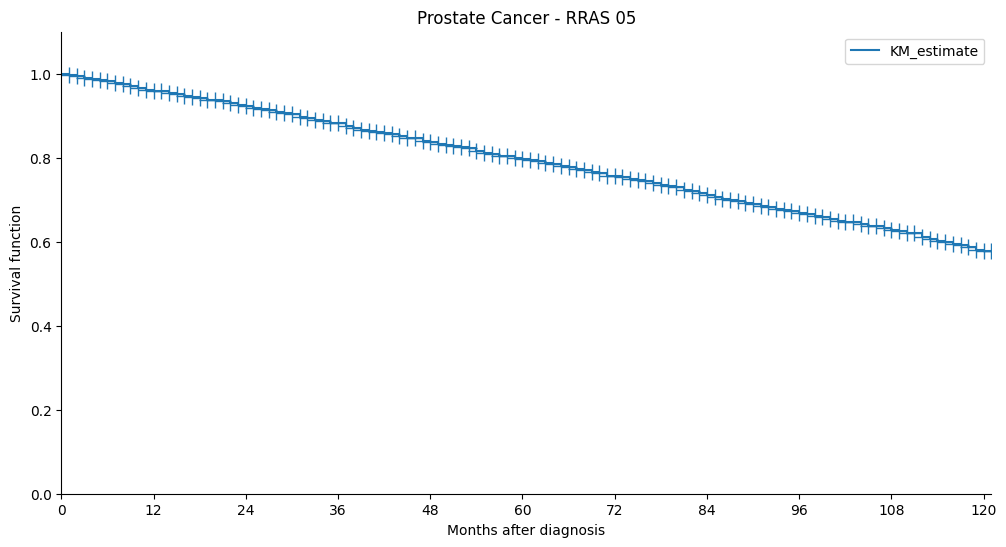

In [ ]:
plot_km_rras(df, 'RRAS 05')

In [ ]:
results_rras.to_csv('results_rras.csv', index=False)

# **Results**

### Selections made:
- Age greater than 19 years;
- State of residence in São Paulo;
- Clinical staging categorized as I, II, III, or IV (excluding in situ cases);
- Patients with microscopic confirmation;
- Patients who did not undergo bone marrow transplantation;
- Topography categorized as ICD-10 C61.

### Initial Database size:
1233793 pacients
### Final database size:
111491 pacients


## Requirements Synchronization

In [ ]:
sync("data_analysis", ["seaborn", "plotly", "scikit-learn", "lifelines"])